# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [51]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element):     
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element):
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [52]:
# ADD AUXILIARY DATA STRUCTURE DEFINITIONS AND HELPER CODE HERE

class TwoThreeNode():
    def __init__(self, value: str):
        self.value = value
        self.left = None
        self.right = None
        # finish




    
# LLRB functions

class LLRBNode():
    def __init__(self, value):
        self.value = value
        self.color = "RED"
        self.left = None
        self.right = None

    def is_red(self): 
        return self.color == "RED"

Use the cell below to implement the requested API by means of **2-3 Tree** (if among your chosen data structure).

In [ ]:
class TwoThreeTree(AbstractSearchInterface):

    def __init__(self):
        self.root = None

    def insertElement(self, element: str) -> bool:
        if self._search(self.root, element):
            return False
        if self.root is None:
            self.root = TwoThreeNode()
            self.root.keys.append(element)
            return True
        result = self._insert(self.root, element)
        if isinstance(result, tuple):
            mid, left, right = result
            new_root = TwoThreeNode()
            new_root.keys.append(mid)
            new_root.children = [left, right]
            self.root = new_root
        return True

    def searchElement(self, element: str) -> bool:
        return self._search(self.root, element)

    def _search(self, node, element):
        if node is None:
            return False
        if element in node.keys:
            return True
        if node.is_leaf():
            return False
        if element < node.keys[0]:
            return self._search(node.children[0], element)
        elif node.is_two_node() or element < node.keys[1]:
            return self._search(node.children[1], element)
        else:
            return self._search(node.children[2], element)

    def _insert(self, node, element):
        if node.is_leaf():
            node.keys.append(element)
            node.keys.sort()
            if len(node.keys) == 3:
                return self._split(node)
            return None

        if element < node.keys[0]:
            idx = 0
            result = self._insert(node.children[0], element)
        elif node.is_two_node() or element < node.keys[1]:
            idx = 1
            result = self._insert(node.children[1], element)
        else:
            idx = 2
            result = self._insert(node.children[2], element)

        if result is None:
            return None

        mid, left, right = result
        node.keys.append(mid)
        node.keys.sort()
        node.children[idx] = left
        node.children.insert(idx + 1, right)

        if len(node.keys) == 3:
            return self._split(node)
        return None

    def _split(self, node):
        mid = node.keys[1]
        left = TwoThreeNode()
        right = TwoThreeNode()
        left.keys = [node.keys[0]]
        right.keys = [node.keys[2]]

        if not node.is_leaf():
            left.children = node.children[:2]
            right.children = node.children[2:]

        return (mid, left, right)

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [54]:
class AVLTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found  

Use the cell below to implement the requested API by means of **LLRB BST** (if among your chosen data structure).

In [55]:
class LLRBBST(AbstractSearchInterface):

    def __init__(self):
        super().__init__()
        self.root = None

    def insertElement(self, element):
        if self.searchElement(element):
            return False

        self.root = self._insertElement(self.root, element)
        self.root.color = "BLACK"
        return True

    def _insertElement(self, node, value):
        ''' Recursive implementation of insert, performs standard BST insert and LLRB validation checks '''
        if node is None:
            return LLRBNode(value)

        if value < node.value:
            node.left = self._insertElement(node.left, value)
        else:
            node.right = self._insertElement(node.right, value)

        if node.right is not None and node.right.is_red() and (node.left is None or not node.left.is_red()):
            node = self.rotate_left(node)
        if node.left is not None and node.left.is_red() and node.left.left is not None and node.left.left.is_red():
            node = self.rotate_right(node)
        if node.left is not None and node.left.is_red() and node.right is not None and node.right.is_red():
            self.colour_flip(node)

        return node

    def rotate_left(self, n: LLRBNode) -> LLRBNode:
        x = n.right
        n.right = x.left
        x.left = n
        x.color = n.color
        n.color = "RED"

        return x

    def rotate_right(self, n: LLRBNode):
        x = n.left
        n.left = x.right
        x.right = n
        x.color = n.color
        n.color = "RED"

        return x

    def colour_flip(self, n: LLRBNode):
        n.color = "RED"
        n.right.color = "BLACK"
        n.left.color = "BLACK"

    def searchElement(self, element):
        node = self.root
        while node is not None:
            if element == node.value:
                return True
            if element < node.value:
                node = node.left
            else:
                node = node.right

        return False

Use the cell below to implement the requested API by means of **B-Tree** (if among your chosen data structure).

In [56]:
class BTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [57]:
class ScapegoatTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found 

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [ ]:
import string
import random

class TestDataGenerator():
    '''
    A class to represent a synthetic data generator.
    ...

    Attributes
    ----------
    
    [to be defined as part of the coursework]

    Methods
    -------
    
    generate_random_string(self, length): returns a string of random characters of a specified length\n
    generate_random_strings(self, length, word_length): returns an list of random strings, of a specified length\n
    generate_not_in_set(self, existing_set, length, word_length): returns list of random strings not in the trees for testing \n
    generate_sorted_strings(self, length, word_length): returns a sorted list of random strings\n
    generate_prefix_strings(self, length, prefix_length, random_suffix_length): returns a list of strings sharing a common prefix\n
    generate_sample_from(self, existing_list, length): returns a random sample of elements known to be in the dataset\n
    '''

    #ADD YOUR CODE HERE
    
    def __init__(self):
        pass

    def generate_random_string(self, length: int) -> str:
        return ''.join(random.choices(string.ascii_letters + string.digits, k=length))
    
    def generate_random_strings(self, length: int, word_length: int=5) -> list[str]:
        return [self.generate_random_string(word_length) for _ in range(length)]
    
    def generate_not_in_set(self, existing_set: set, length: int, word_length: int=5) -> list[str]:
        ''' Testing edge case - item we look for is not in tree'''

        data = []
        # while loop instead of for loop, ensures list doesn't get shorter by skipping values that are already in tree
        while len(data) < length:
            item = self.generate_random_string(word_length)
            if item not in existing_set:
                data.append(item)
        return data
    
    def generate_sorted_strings(self, length: int, word_length: int=5) -> list[str]:
        '''Testing edge case - sequential inserts. Tree will be very imbalanced.'''
        data = self.generate_random_strings(length, word_length)
        data.sort() 
        return data
    
    def generate_prefix_strings(self, length: int, prefix_length: int=15, random_suffix_length: int=5) -> list[str]:
        '''Testing edge case - heavy collision/expensive comparison.'''
        prefix = self.generate_random_string(prefix_length)
        data = []
        for _ in range(length):
            suffix = self.generate_random_string(random_suffix_length)
            data.append(prefix + suffix)
        return data

    def generate_sample_from(self, existing_list: list, length: int) -> list[str]:
        '''Generates a sample of elements that are guaranteed to be in the tree (Successful search).'''
        # If we need more samples than exist in the list, we allow duplicate sampling
        if length > len(existing_list):
            return random.choices(existing_list, k=length)
        else:
            return random.sample(existing_list, k=length)

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

In [ ]:
import timeit
import matplotlib.pyplot as plt

class ExperimentalFramework():
    '''
    A class to represent an experimental framework.
    ...

    Attributes
    ----------
    
    data_generator: TestDataGenerator instance for generating test data
    tree_classes: dict mapping tree names to their classes
    test_sizes: list of dataset sizes to test

    Methods
    -------
    
    build_tree(tree, data): Inserts data into tree, returns time taken\n
    measure_search_time(tree, elements): Measures average search time\n
    run_full_experiment(tree_name, size, datatype): Runs single experiment\n
    run_all_sizes(tree_name, data_type): Runs experiment for all sizes\n
    run_all_trees(): Runs all experiments for all trees and data types\n
    run_experiment_with_stats(tree_name, size, datatype, num_runs): Runs with statistical analysis\n
    run_all_trees_with_stats(num_runs): Full experiment suite with statistics\n
    run_edge_case_tests(tree_name): Tests edge cases\n
    plot_insert_times(results): Plots insertion time vs dataset size\n
    plot_search_times(results): Plots search times across all scenarios\n
    plot_search_comparison_bars(results, size): Bar chart comparisons\n
    plot_insertion_per_element(results): Per-element insertion cost\n
    plot_summary_heatmap(results, metric, size): Heatmap visualization\n
    plot_insert_times_with_error(results): Plots with error bars\n
    generate_full_report(num_runs): Generates complete analysis\n
    '''
            
    def __init__(self):
        self.data_generator = TestDataGenerator()

        # Defines tree classes, not instances, so a fresh instance can be created on each trial run
        self.tree_classes = {"LLRB" : LLRBBST,
                               #"TwoThree" : TwoThreeTree,
                               # "AVL" : AVLTree
                            }
        self.test_sizes = [1000, 5000, 10000, 25000, 50000]

    def build_tree(self, tree: AbstractSearchInterface, data):
        ''' Inserts data into a tree, returns the time taken'''
        t1 = timeit.default_timer()
        for item in data:
            tree.insertElement(item)
        t2 = timeit.default_timer()
        return t2 - t1
    
    def measure_search_time(self, tree: AbstractSearchInterface, elements):
        ''' Measures average time of searching for a list of elements in a given tree.'''
        t1 = timeit.default_timer()
        for element in elements:
            tree.searchElement(element)
        t2 = timeit.default_timer()
        average_time = (t2 - t1) / len(elements)
        return average_time
    
    def run_full_experiment(self, tree_name, size, datatype="random"):
        ''' Instantiates a tree of a specific size, inserts data (measuring time taken), measures search times.'''
        new_tree: AbstractSearchInterface = self.tree_classes[tree_name]()

        if datatype == "random":
            tree_data = self.data_generator.generate_random_strings(size)
        elif datatype == "sorted":
            tree_data = self.data_generator.generate_sorted_strings(size)
        elif datatype == "prefix":
            tree_data = self.data_generator.generate_prefix_strings(size)

        insert_time = self.build_tree(new_tree, tree_data)
        results = {"insert_time": insert_time}

        search_elements_length = 1000
        existing_set = set(tree_data)

        search_elements = {
            "random": self.data_generator.generate_random_strings(search_elements_length),
            "not_in_set": self.data_generator.generate_not_in_set(existing_set, search_elements_length),
            "prefix": self.data_generator.generate_prefix_strings(search_elements_length),
            "in_set": self.data_generator.generate_sample_from(tree_data, search_elements_length)
        }

        for label, elements in search_elements.items():
            results[label] = self.measure_search_time(new_tree, elements)

        return results
    
    def run_all_sizes(self, tree_name, data_type="random"):
        ''' Completes run_full_experiment() on a specific tree for all test lengths'''
        results = {}
        for size in self.test_sizes:
            results[size] = self.run_full_experiment(tree_name, size, data_type)
        return results

    def run_all_trees(self):
        ''' Completes run_all_sizes() for all trees. Produces all data required for comparison'''
        results = {}
        for tree_class in self.tree_classes:
            results[tree_class] = {}
            for data_type in ["random", "sorted", "prefix"]:
                results[tree_class][data_type] = self.run_all_sizes(tree_class, data_type)
        return results

    # stats methods

    def run_experiment_with_stats(self, tree_name, size, datatype="random", num_runs=5):
        '''
        Runs the experiment multiple times and computes statistics.
        Returns mean and standard deviation for each metric.
        '''
        all_results = []
        
        for _ in range(num_runs):
            result = self.run_full_experiment(tree_name, size, datatype)
            all_results.append(result)
        
        metrics = all_results[0].keys()
        stats = {}
        
        for metric in metrics:
            values = [r[metric] for r in all_results]
            mean = sum(values) / len(values)
            variance = sum((x - mean) ** 2 for x in values) / len(values)
            std_dev = variance ** 0.5
            
            stats[metric] = {
                "mean": mean,
                "std": std_dev,
                "min": min(values),
                "max": max(values)
            }
        
        return stats

    def run_all_sizes_with_stats(self, tree_name, data_type="random", num_runs=5):
        '''Runs experiments with statistical analysis for all sizes.'''
        results = {}
        for size in self.test_sizes:
            results[size] = self.run_experiment_with_stats(tree_name, size, data_type, num_runs)
        return results

    def run_all_trees_with_stats(self, num_runs=5):
        '''Full experiment suite with statistical robustness.'''
        results = {}
        for tree_class in self.tree_classes:
            results[tree_class] = {}
            for data_type in ["random", "sorted", "prefix"]:
                results[tree_class][data_type] = self.run_all_sizes_with_stats(tree_class, data_type, num_runs)
        return results

    # edge cases

    def run_edge_case_tests(self, tree_name):
        '''Tests edge cases for thorough analysis'''
        results = {}
        
        # edge case 1: Single element tree
        tree = self.tree_classes[tree_name]()
        tree.insertElement("single_element")
        t1 = timeit.default_timer()
        tree.searchElement("single_element")
        t2 = timeit.default_timer()
        tree.searchElement("not_present")
        t3 = timeit.default_timer()
        results["single_element_success"] = t2 - t1
        results["single_element_fail"] = t3 - t2
        
        # edge case 2: Duplicate insertions (should return False)
        tree = self.tree_classes[tree_name]()
        data = self.data_generator.generate_random_strings(1000)
        for item in data:
            tree.insertElement(item)
        
        t1 = timeit.default_timer()
        duplicate_results = [tree.insertElement(item) for item in data[:100]]
        t2 = timeit.default_timer()
        results["duplicate_insert_time"] = t2 - t1
        results["duplicate_insert_all_false"] = all(r == False for r in duplicate_results)
        
        # edge case 3: Search for first vs last inserted element
        tree = self.tree_classes[tree_name]()
        random_data = self.data_generator.generate_random_strings(10000)
        for item in random_data:
            tree.insertElement(item)
        
        t1 = timeit.default_timer()
        for _ in range(1000):
            tree.searchElement(random_data[0])
        t2 = timeit.default_timer()
        results["search_first_element"] = (t2 - t1) / 1000
        
        t1 = timeit.default_timer()
        for _ in range(1000):
            tree.searchElement(random_data[-1])
        t2 = timeit.default_timer()
        results["search_last_element"] = (t2 - t1) / 1000
        
        return results

    # Plotting functions

    def plot_insert_times(self, results):
        ''' Plots total insertion time vs tree size, one line per tree+datatype combination '''
        plt.figure(figsize=(10, 6))

        for tree_name, datatype_results in results.items():
            for data_type, size_results in datatype_results.items():
                sizes = sorted(size_results.keys())
                times = [size_results[size]["insert_time"] for size in sizes]
                plt.plot(sizes, times, marker='o', label=f"{tree_name} ({data_type})")

        plt.xlabel("Number of elements inserted")
        plt.ylabel("Total insertion time (seconds)")
        plt.title("Insertion Time vs Dataset Size")
        plt.xticks(self.test_sizes)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_search_times(self, results):
        '''
        Plots average search time vs tree size for each search type.
        Creates a subplot grid: rows = search types, columns = data types
        '''
        search_metrics = ["random", "not_in_set", "prefix", "in_set"]
        data_types = ["random", "sorted", "prefix"]
        
        fig, axes = plt.subplots(len(search_metrics), len(data_types), 
                                  figsize=(15, 12), sharex=True)
        
        for row, search_metric in enumerate(search_metrics):
            for col, data_type in enumerate(data_types):
                ax = axes[row, col]
                
                for tree_name in results.keys():
                    sizes = sorted(results[tree_name][data_type].keys())
                    times = [results[tree_name][data_type][size].get(search_metric, 0) 
                             for size in sizes]
                    ax.plot(sizes, times, marker='o', label=tree_name)
                
                ax.set_title(f"Search: {search_metric} | Data: {data_type}")
                ax.set_ylabel("Avg Search Time (s)")
                ax.legend()
                ax.grid(True)
                
                if row == len(search_metrics) - 1:
                    ax.set_xlabel("Dataset Size")
        
        plt.tight_layout()
        plt.show()

    def plot_search_comparison_bars(self, results, size=10000):
        '''
        Bar chart comparing all trees for a specific dataset size.
        Groups bars by search type, colored by tree.
        '''
        search_metrics = ["random", "not_in_set", "prefix", "in_set"]
        data_types = ["random", "sorted", "prefix"]
        tree_names = list(results.keys())
        
        fig, axes = plt.subplots(1, len(data_types), figsize=(15, 5))
        
        if len(data_types) == 1:
            axes = [axes]
        
        bar_width = 0.8 / max(len(tree_names), 1)
        x = range(len(search_metrics))
        
        for col, data_type in enumerate(data_types):
            ax = axes[col]
            
            for i, tree_name in enumerate(tree_names):
                times = [results[tree_name][data_type][size].get(metric, 0) 
                         for metric in search_metrics]
                positions = [pos + i * bar_width for pos in x]
                ax.bar(positions, times, bar_width, label=tree_name)
            
            ax.set_xlabel("Search Type")
            ax.set_ylabel("Avg Search Time (s)")
            ax.set_title(f"Data Type: {data_type} (n={size})")
            ax.set_xticks([pos + bar_width * (len(tree_names) - 1) / 2 for pos in x])
            ax.set_xticklabels(search_metrics, rotation=45, ha='right')
            ax.legend()
            ax.grid(True, axis='y')
        
        plt.tight_layout()
        plt.show()

    def plot_insertion_per_element(self, results):
        '''
        Plots per-element insertion time (total_time / size) to show 
        how insertion cost scales with tree size.
        '''
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # subplot 1: absolute per-element time
        ax1 = axes[0]
        for tree_name, datatype_results in results.items():
            for data_type, size_results in datatype_results.items():
                sizes = sorted(size_results.keys())
                per_element_times = [size_results[size]["insert_time"] / size 
                                      for size in sizes]
                ax1.plot(sizes, per_element_times, marker='o', 
                         label=f"{tree_name} ({data_type})")
        
        ax1.set_xlabel("Dataset Size")
        ax1.set_ylabel("Time per Element (s)")
        ax1.set_title("Per-Element Insertion Time")
        ax1.legend()
        ax1.grid(True)
        
        # subplot 2: log-log scale for complexity analysis
        ax2 = axes[1]
        for tree_name, datatype_results in results.items():
            for data_type, size_results in datatype_results.items():
                sizes = sorted(size_results.keys())
                times = [size_results[size]["insert_time"] for size in sizes]
                ax2.loglog(sizes, times, marker='o', 
                           label=f"{tree_name} ({data_type})")
        
        ax2.set_xlabel("Dataset Size (log)")
        ax2.set_ylabel("Total Insertion Time (log)")
        ax2.set_title("Insertion Time (Log-Log Scale)")
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()

    def plot_summary_heatmap(self, results, metric="insert_time", size=10000):
        '''
        Creates a heatmap showing performance across trees and data types.
        '''
        tree_names = list(results.keys())
        data_types = ["random", "sorted", "prefix"]
        
        # build matrix
        matrix = []
        for tree_name in tree_names:
            row = [results[tree_name][dt][size].get(metric, 0) for dt in data_types]
            matrix.append(row)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')
        
        # labels
        ax.set_xticks(range(len(data_types)))
        ax.set_yticks(range(len(tree_names)))
        ax.set_xticklabels(data_types)
        ax.set_yticklabels(tree_names)
        
        # add text annotations
        for i in range(len(tree_names)):
            for j in range(len(data_types)):
                text = f"{matrix[i][j]:.6f}"
                ax.text(j, i, text, ha="center", va="center", color="black", fontsize=9)
        
        plt.colorbar(im, label=f"{metric} (seconds)")
        plt.title(f"{metric} Heatmap (n={size})")
        plt.tight_layout()
        plt.show()

    def plot_insert_times_with_error(self, results_with_stats):
        '''
        Plots insertion time with error bars showing standard deviation.
        Requires results from run_all_trees_with_stats().
        '''
        plt.figure(figsize=(12, 6))
        
        for tree_name, datatype_results in results_with_stats.items():
            for data_type, size_results in datatype_results.items():
                sizes = sorted(size_results.keys())
                means = [size_results[size]["insert_time"]["mean"] for size in sizes]
                stds = [size_results[size]["insert_time"]["std"] for size in sizes]
                
                plt.errorbar(sizes, means, yerr=stds, marker='o', capsize=5,
                             label=f"{tree_name} ({data_type})")
        
        plt.xlabel("Number of Elements")
        plt.ylabel("Insertion Time (s)")
        plt.title("Insertion Time with Standard Deviation")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # report generation
    # !!! this one screams of AI. careful with it

    def generate_full_report(self, num_runs=3):
        '''
        Generates a complete visual report with all plots.
        '''
        print("Running experiments (single run for basic plots)...")
        results_simple = self.run_all_trees()
        
        print("\nInsertion performance")
        self.plot_insert_times(results_simple)
        self.plot_insertion_per_element(results_simple)
        
        print("\nSearch performance")
        self.plot_search_times(results_simple)
        
        print("\nComparative Analysis")
        for size in self.test_sizes:
            print(f"Bar chart for size {size}:")
            self.plot_search_comparison_bars(results_simple, size=size)
        
        print("\nSummary Heatmaps")
        for metric in ["insert_time", "in_set", "not_in_set"]:
            for size in [1000, 50000]:
                self.plot_summary_heatmap(results_simple, metric=metric, size=size)
        
        print("\nEdge case analysis")
        for tree_name in self.tree_classes:
            edge_results = self.run_edge_case_tests(tree_name)
            print(f"\n{tree_name} Edge Cases:")
            for key, value in edge_results.items():
                print(f"  {key}: {value}")
        
        print(f"\nRunning experiments with statistics ({num_runs} runs each)...")
        results_with_stats = self.run_all_trees_with_stats(num_runs)
        
        print("\nStatistical Analysis")
        self.plot_insert_times_with_error(results_with_stats)
        
        return results_simple, results_with_stats

    def main(self):
        results = self.run_all_trees()
        self.plot_insert_times(results)

Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.

Running experiments (single run for basic plots)...

=== INSERTION PERFORMANCE ===


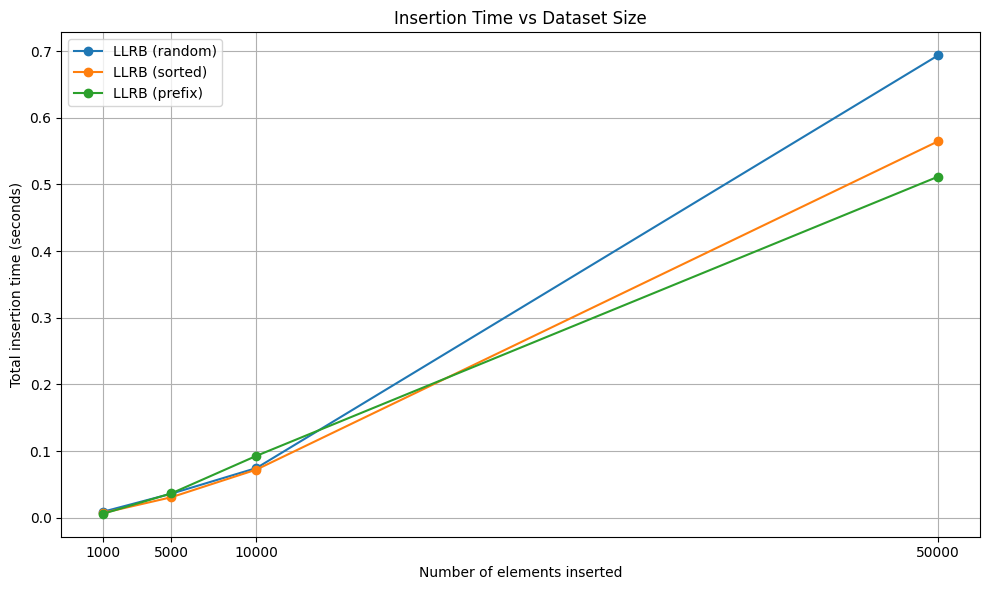

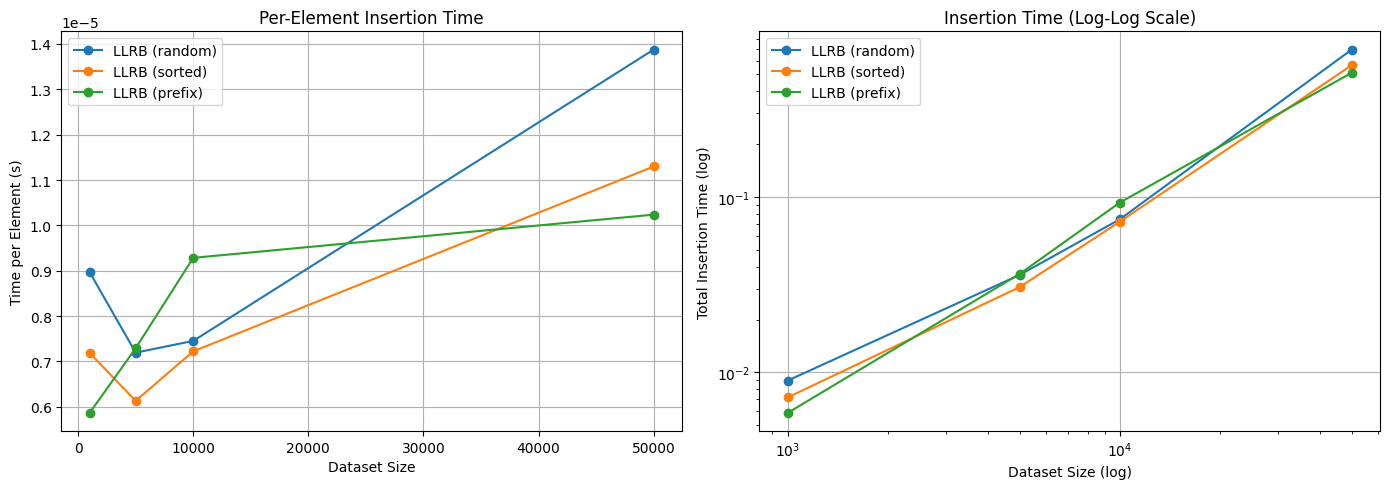


=== SEARCH PERFORMANCE ===


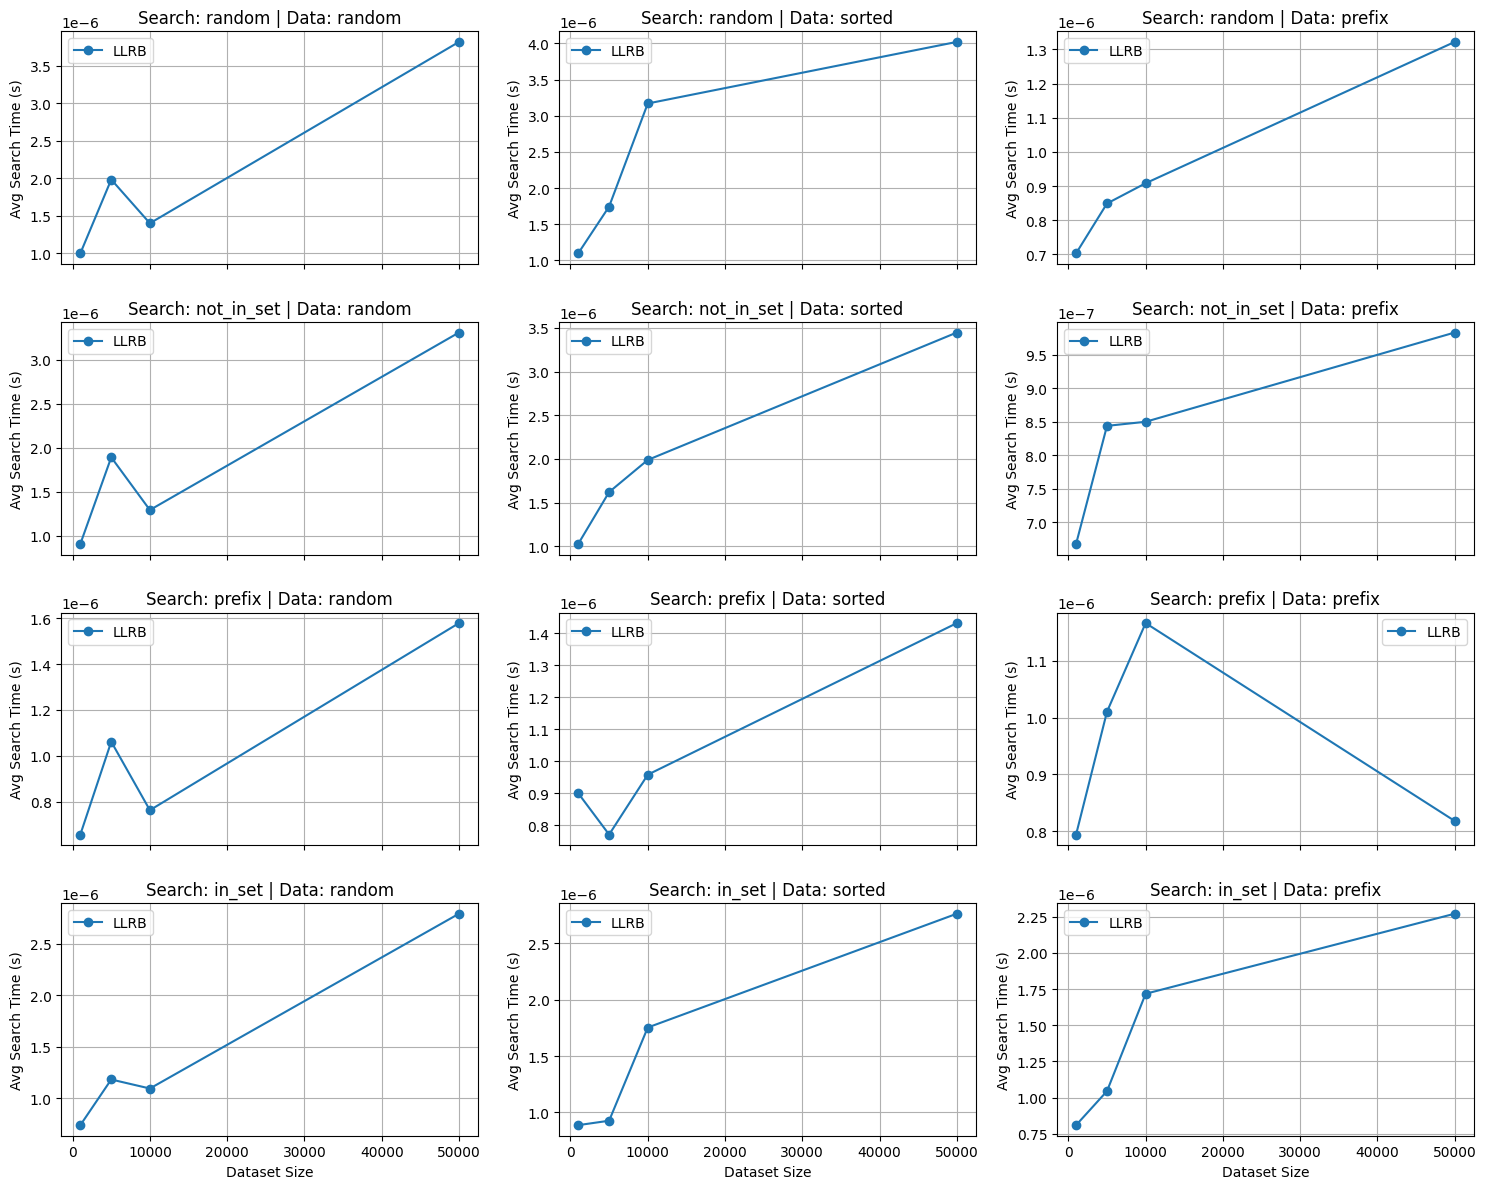


=== COMPARATIVE ANALYSIS ===
Bar chart for size 1000:


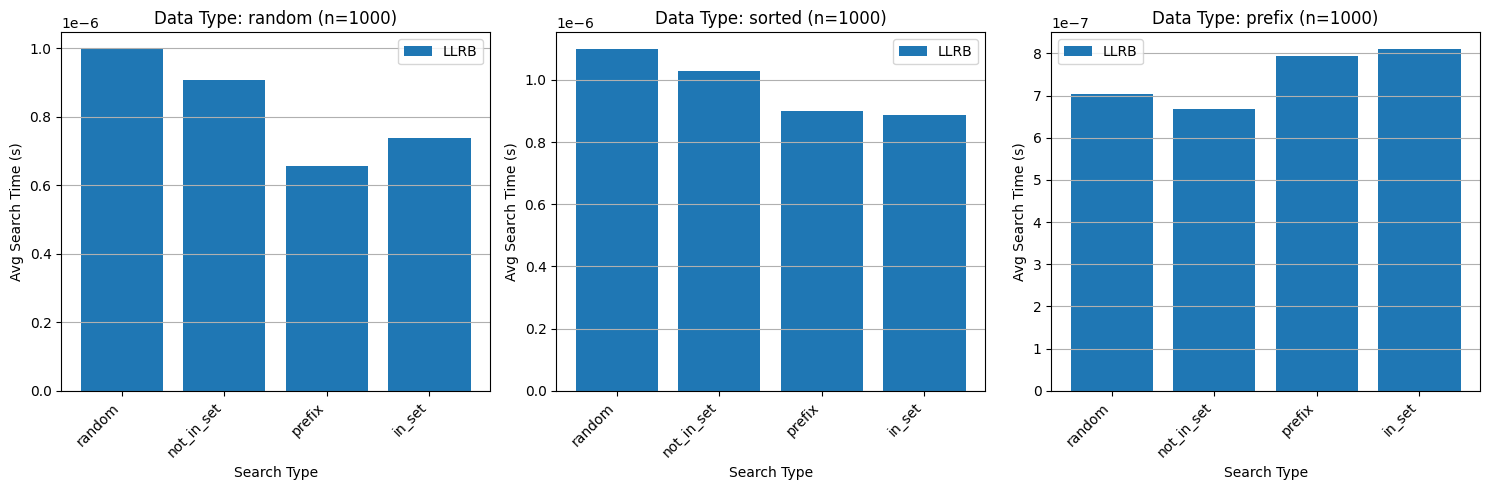

Bar chart for size 5000:


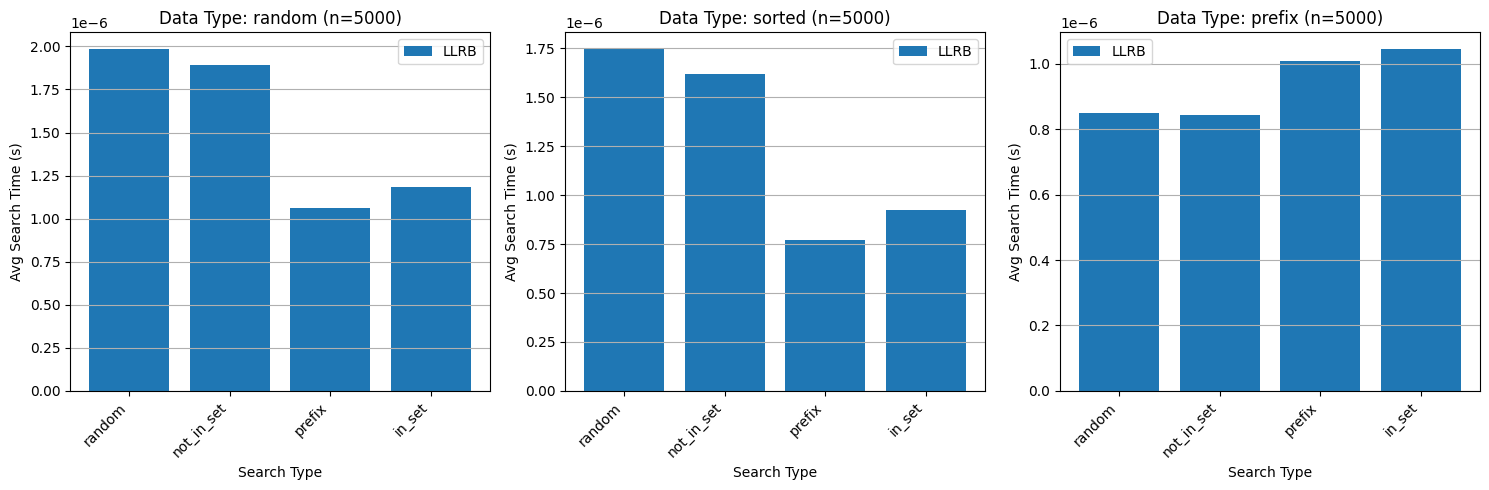

Bar chart for size 10000:


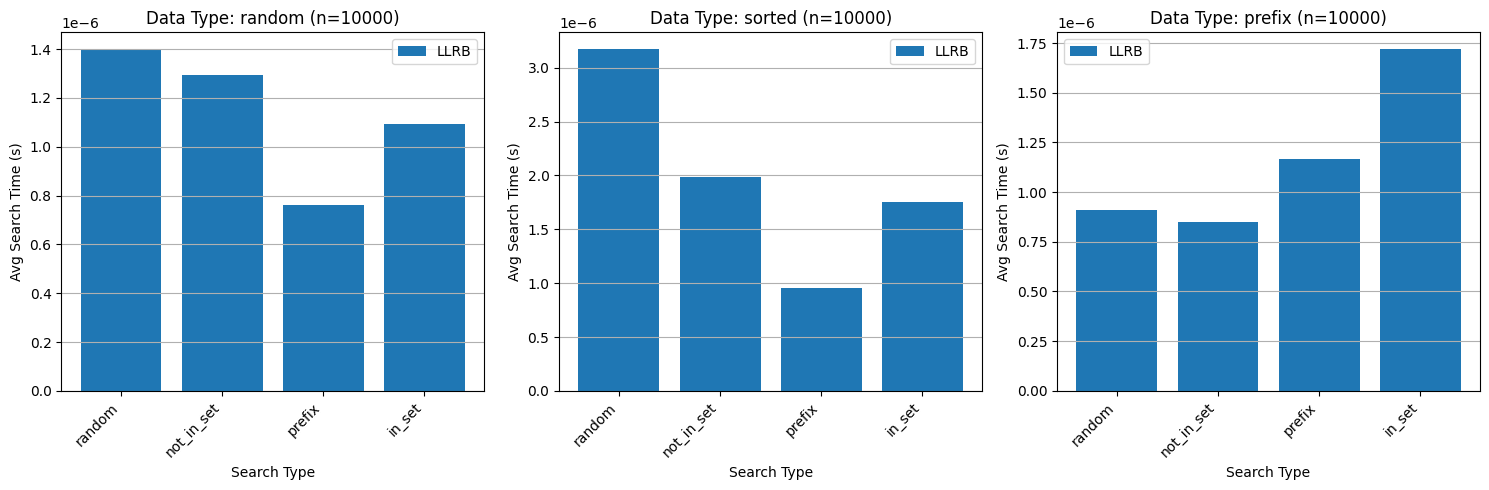

Bar chart for size 50000:


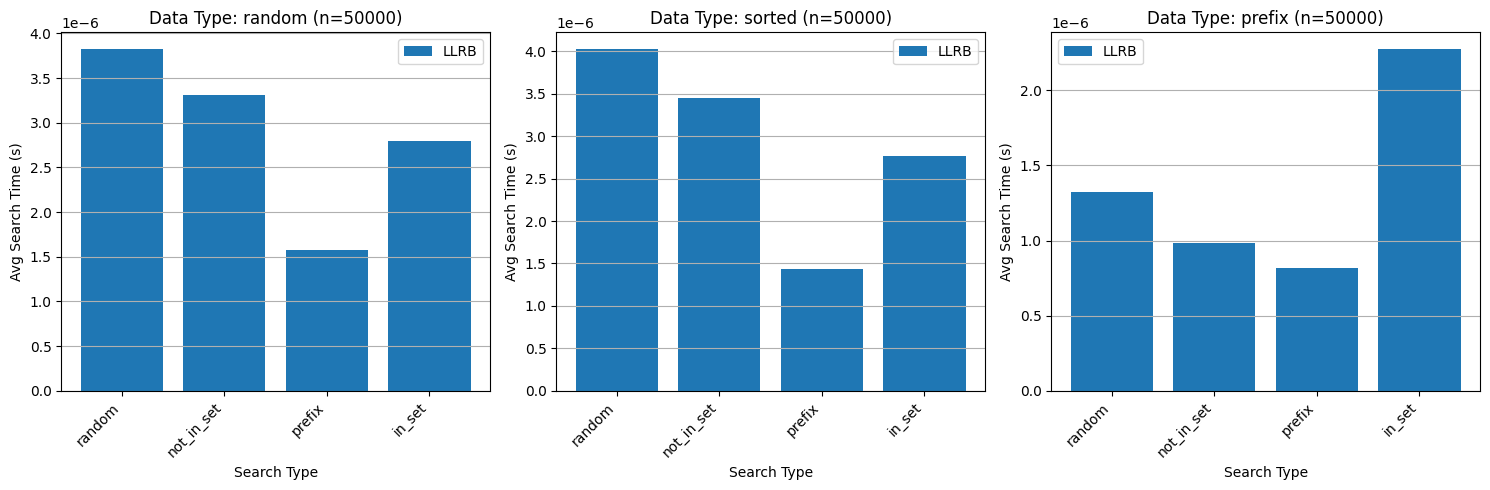


=== SUMMARY HEATMAPS ===


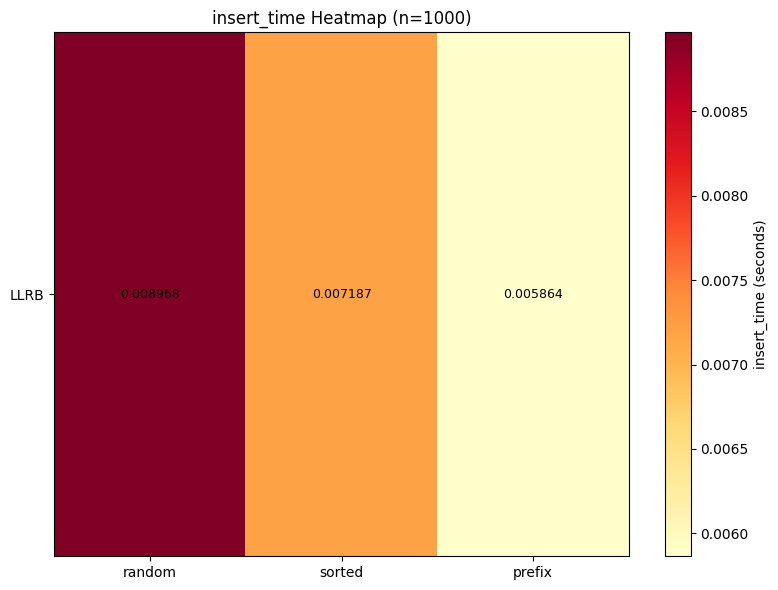

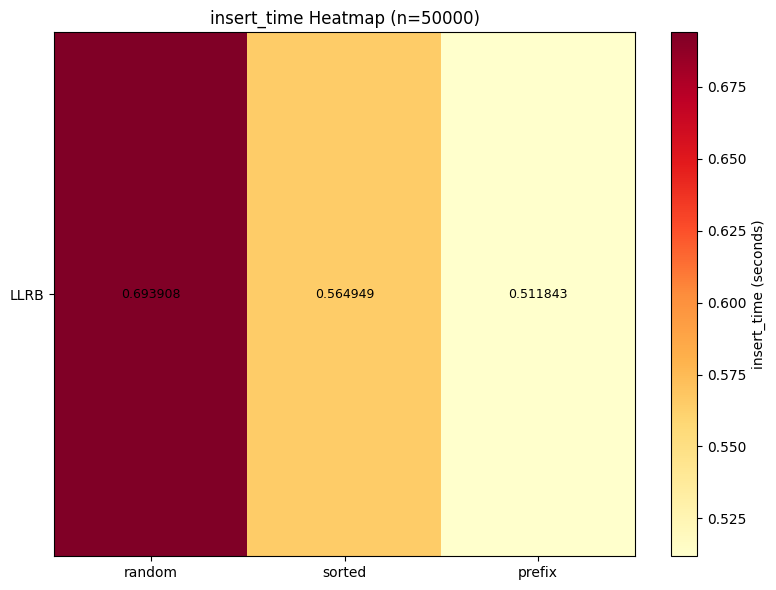

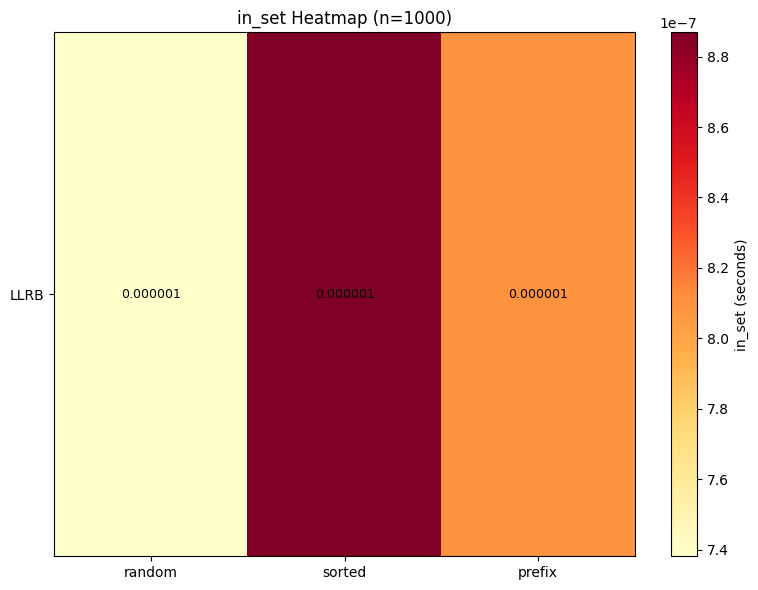

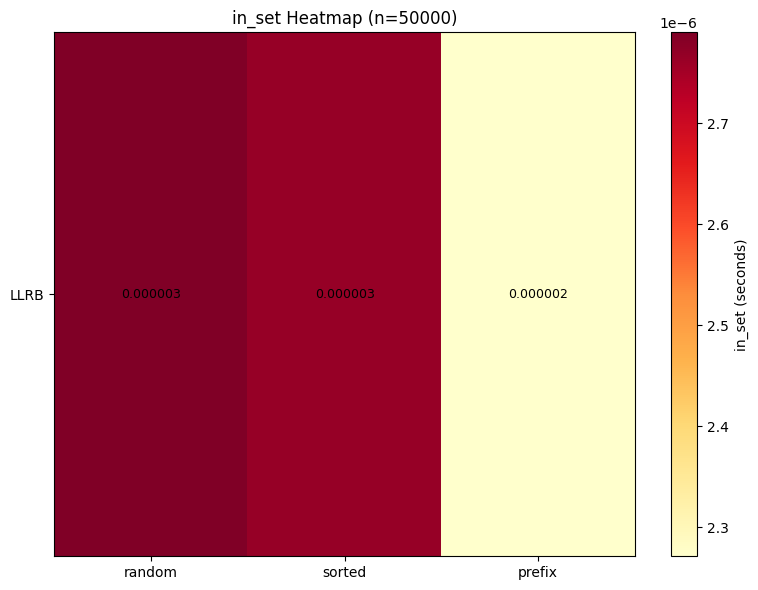

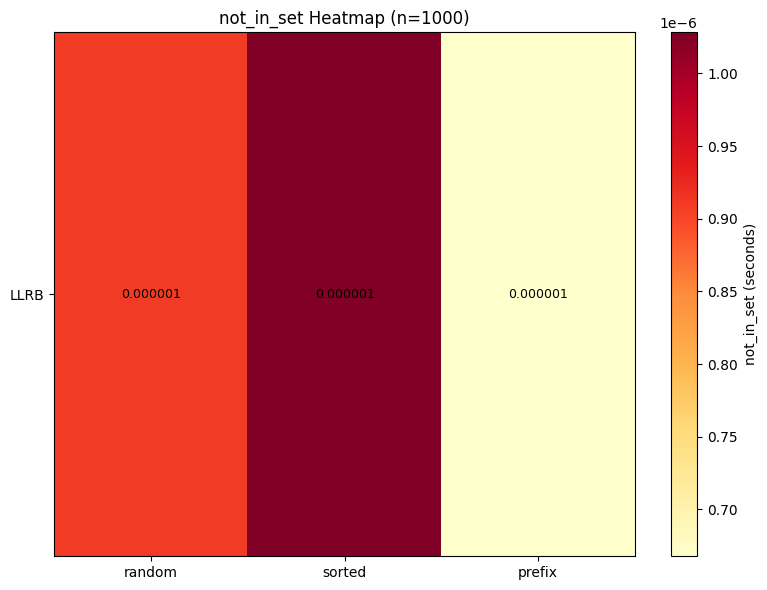

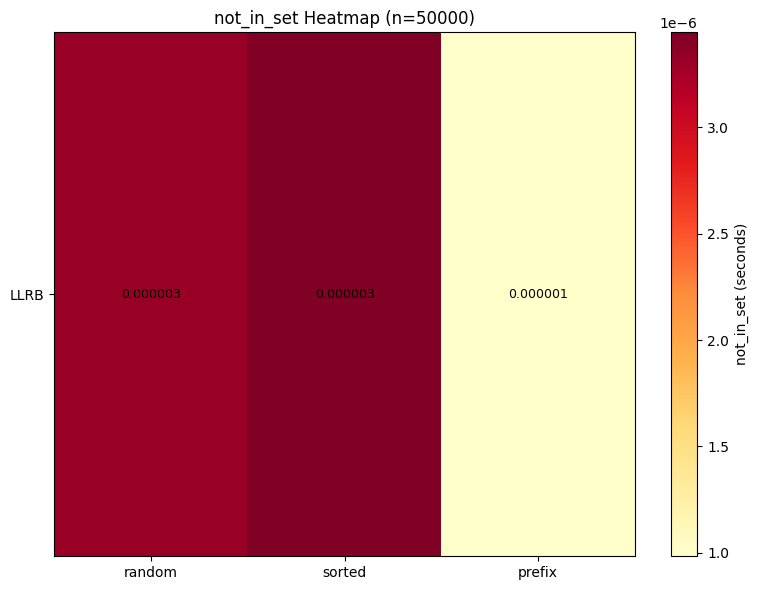


=== EDGE CASE ANALYSIS ===

LLRB Edge Cases:
  single_element_success: 6.998889148235321e-07
  single_element_fail: 9.0012326836586e-07
  duplicate_insert_time: 8.569983765482903e-05
  duplicate_insert_all_false: True
  search_first_element: 3.0580000020563604e-07
  search_last_element: 1.3557001948356629e-06

Running experiments with statistics (3 runs each)...

=== STATISTICAL ANALYSIS ===


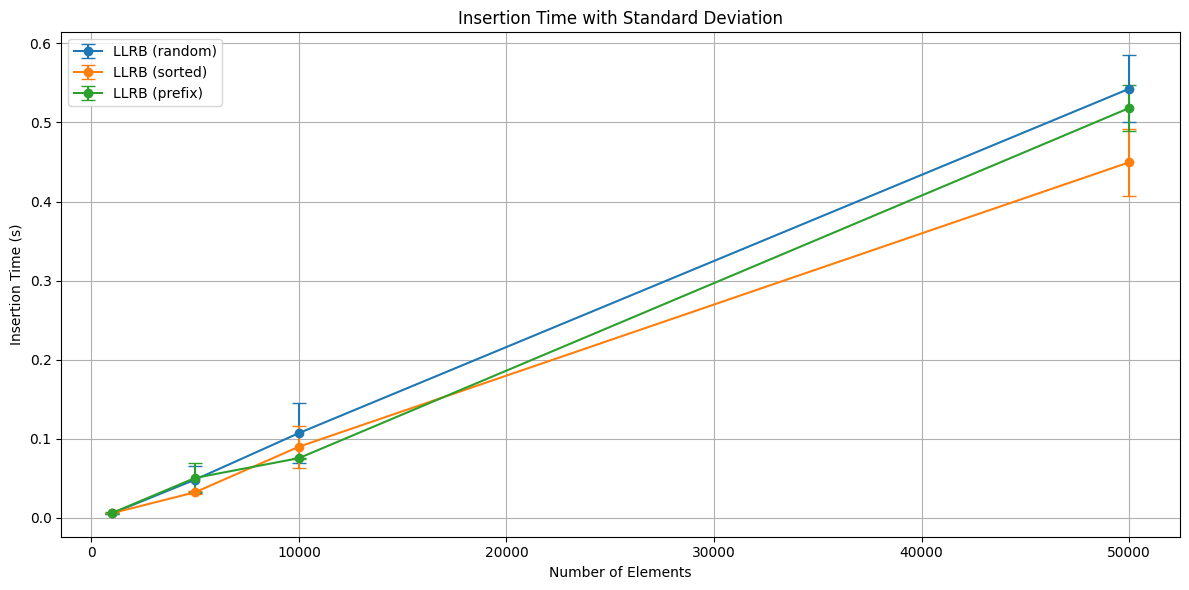

In [ ]:
# ADD YOUR TEST CODE HERE

framework = ExperimentalFramework()

# framework.main()

# comprehensive report with all plots and statistics
results_simple, results_with_stats = framework.generate_full_report(num_runs=3)